In [16]:
setwd("~/Projects/R/ISLR2")

In [17]:
source("InstallAndLoadScripts/loadlibraries.R")

In [18]:
loadISLR2Libraries()

In [19]:
print(as_tibble(Smarket))
attach(Smarket)

# A tibble: 1,250 × 9
    Year   Lag1   Lag2   Lag3   Lag4   Lag5 Volume  Today Direction
   <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl>  <dbl> <fct>    
 1  2001  0.381 -0.192 -2.62  -1.06   5.01    1.19  0.959 Up       
 2  2001  0.959  0.381 -0.192 -2.62  -1.06    1.30  1.03  Up       
 3  2001  1.03   0.959  0.381 -0.192 -2.62    1.41 -0.623 Down     
 4  2001 -0.623  1.03   0.959  0.381 -0.192   1.28  0.614 Up       
 5  2001  0.614 -0.623  1.03   0.959  0.381   1.21  0.213 Up       
 6  2001  0.213  0.614 -0.623  1.03   0.959   1.35  1.39  Up       
 7  2001  1.39   0.213  0.614 -0.623  1.03    1.44 -0.403 Down     
 8  2001 -0.403  1.39   0.213  0.614 -0.623   1.41  0.027 Up       
 9  2001  0.027 -0.403  1.39   0.213  0.614   1.16  1.30  Up       
10  2001  1.30   0.027 -0.403  1.39   0.213   1.23  0.287 Up       
# ℹ 1,240 more rows


The following objects are masked from Smarket (pos = 3):

    Direction, Lag1, Lag2, Lag3, Lag4, Lag5, Today, Volume, Year




In [20]:
glm01 = glm(Direction ~ . - Year - Today, data = Smarket, family=binomial)
print(summary(glm01))


Call:
glm(formula = Direction ~ . - Year - Today, family = binomial, 
    data = Smarket)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept) -0.126000   0.240736  -0.523    0.601
Lag1        -0.073074   0.050167  -1.457    0.145
Lag2        -0.042301   0.050086  -0.845    0.398
Lag3         0.011085   0.049939   0.222    0.824
Lag4         0.009359   0.049974   0.187    0.851
Lag5         0.010313   0.049511   0.208    0.835
Volume       0.135441   0.158360   0.855    0.392

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1731.2  on 1249  degrees of freedom
Residual deviance: 1727.6  on 1243  degrees of freedom
AIC: 1741.6

Number of Fisher Scoring iterations: 3



In [21]:
print(coef(glm01))

 (Intercept)         Lag1         Lag2         Lag3         Lag4         Lag5 
-0.126000257 -0.073073746 -0.042301344  0.011085108  0.009358938  0.010313068 
      Volume 
 0.135440659 


In [22]:
preds01 <- predict(glm01 , type = "response")
print(preds01[1:10])

        1         2         3         4         5         6         7         8 
0.5070841 0.4814679 0.4811388 0.5152224 0.5107812 0.5069565 0.4926509 0.5092292 
        9        10 
0.5176135 0.4888378 


In [23]:
print(contrasts(Direction))

     Up
Down  0
Up    1


In [24]:
glm.pred = rep("Down", 1250)
glm.pred[preds01 > .5] = "Up"
print(table(glm.pred , Direction ))

        Direction
glm.pred Down  Up
    Down  145 141
    Up    457 507


In [25]:
train = (Year < 2005)
Smarket.2005 = Smarket[!train,]
dim(Smarket.2005)
Direction.2005 = Smarket$Direction[!train]

[1] 252   9

In [26]:
glm02 = glm(Direction ~ . - Year - Today, data = Smarket, family = binomial, subset = train)

In [27]:
print(summary(glm02))


Call:
glm(formula = Direction ~ . - Year - Today, family = binomial, 
    data = Smarket, subset = train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept)  0.191213   0.333690   0.573    0.567
Lag1        -0.054178   0.051785  -1.046    0.295
Lag2        -0.045805   0.051797  -0.884    0.377
Lag3         0.007200   0.051644   0.139    0.889
Lag4         0.006441   0.051706   0.125    0.901
Lag5        -0.004223   0.051138  -0.083    0.934
Volume      -0.116257   0.239618  -0.485    0.628

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1383.3  on 997  degrees of freedom
Residual deviance: 1381.1  on 991  degrees of freedom
AIC: 1395.1

Number of Fisher Scoring iterations: 3



In [28]:
glm.probs = predict(glm02, Smarket.2005, type = "response")
print(glm.probs[1:10])

      999      1000      1001      1002      1003      1004      1005      1006 
0.5282195 0.5156688 0.5226521 0.5138543 0.4983345 0.5010912 0.5027703 0.5095680 
     1007      1008 
0.5040112 0.5106408 


In [29]:
glm.pred = rep("Down", 252)
glm.pred[glm.probs > .5] = "Up"

In [30]:
print(table(glm.pred, Direction.2005))

        Direction.2005
glm.pred Down Up
    Down   77 97
    Up     34 44


In [31]:
print(mean(glm.pred == Direction.2005))

[1] 0.4801587


In [32]:
print(mean(glm.pred != Direction.2005))

[1] 0.5198413


In [33]:
# artificial data
df <- data.frame(x = c(1:100))
df$y <- 2 + 3 * df$x + rnorm(100, sd = 40)
df$yy <- 2 + 3 * df$x + 0.1 * df$x^2 + rnorm(100, sd = 40)

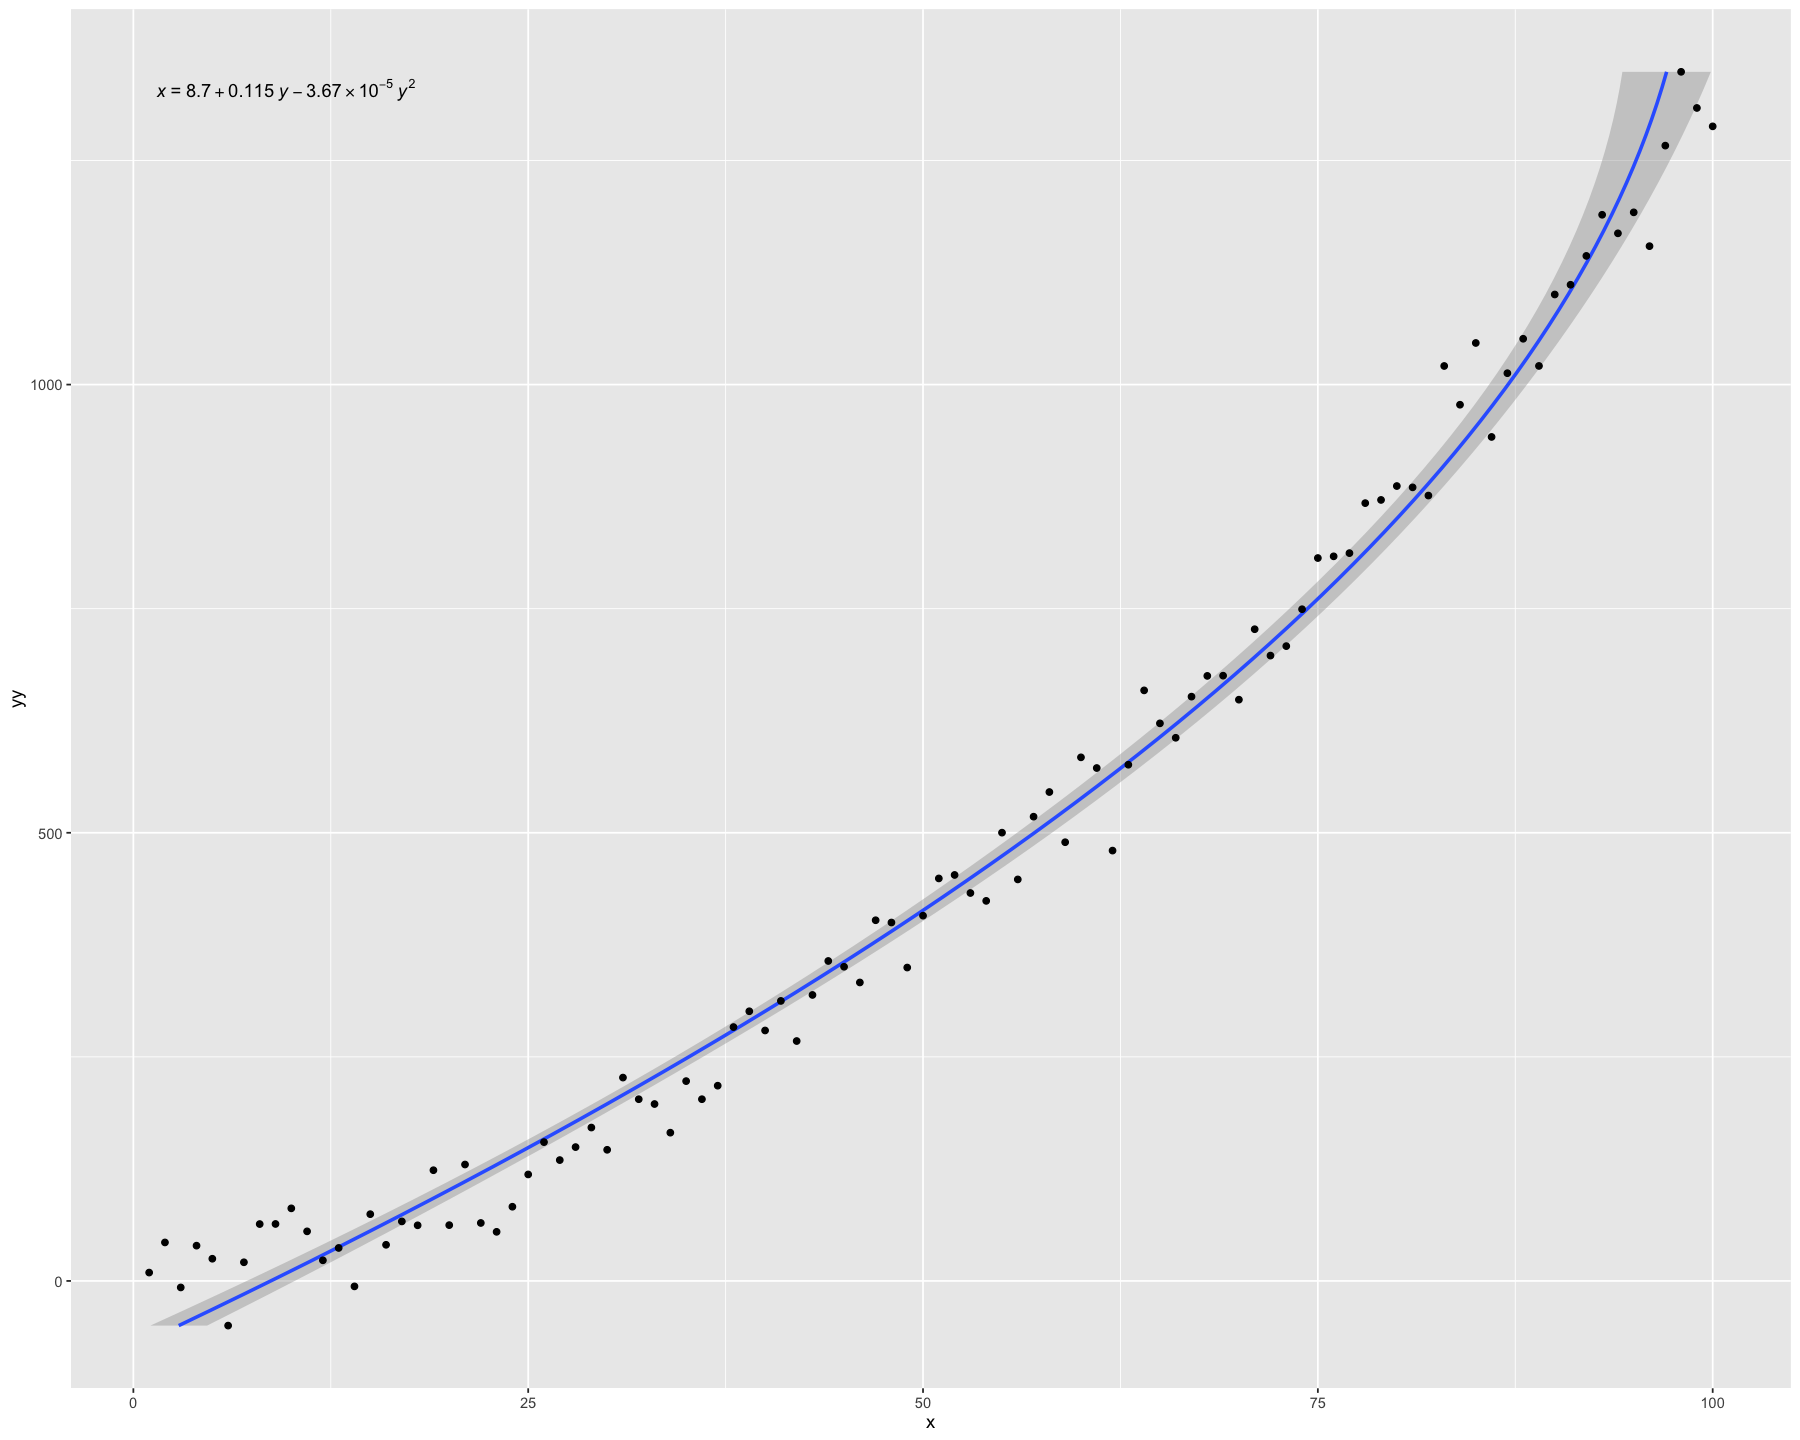

In [43]:
# fitting a polynomial
options(repr.plot.width = 15, repr.plot.height = 12)
f1 = ggplot(data = df, aes(x = x, y = yy)) +
  stat_poly_line(formula = x ~ poly(y, 2, raw = TRUE)) +
  stat_poly_eq(formula = x ~ poly(y, 2, raw = TRUE), use_label("eq")) +
  geom_point()
  
print(f1)

In [35]:
#Boston
df2 <- Boston
df2$x <- df2$lstat
df2$y <- 34.55384 - 0.95 * df2$lstat
df2$yy <- 42.862 - 2.333 * df2$lstat + 0.0435 * df2$lstat^2
 

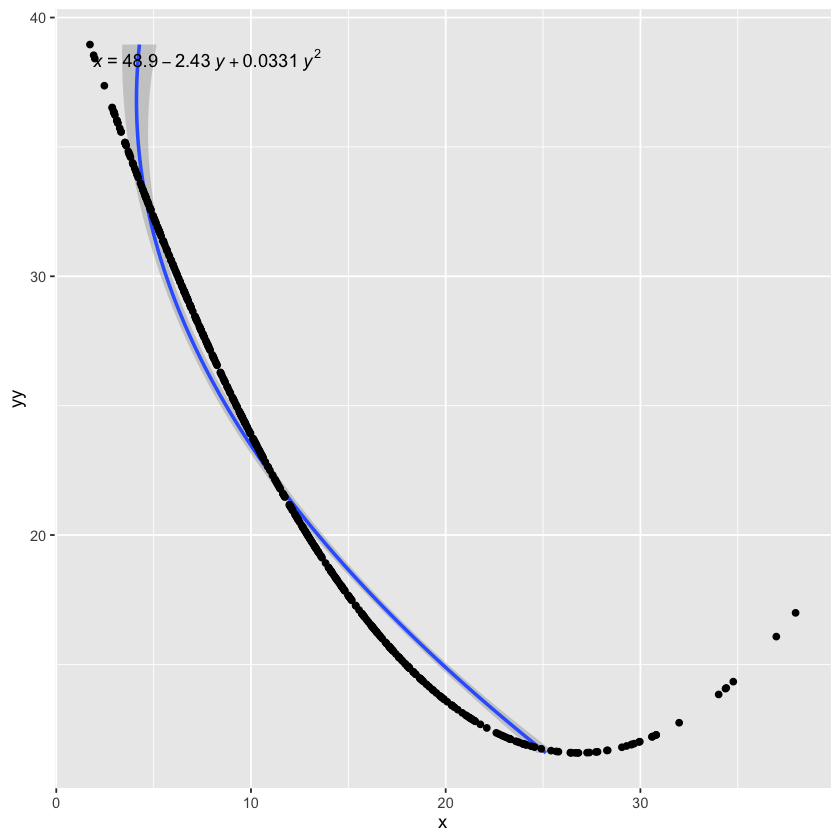

In [36]:
f2 = ggplot(data = df2, aes(x = x, y = yy)) +
  stat_poly_line(formula = x ~ poly(y, 2, raw = TRUE)) +
  stat_poly_eq(formula = x ~ poly(y, 2, raw = TRUE), use_label("eq")) +
  geom_point()

print(f2)

In [37]:
devnum = c()
for (def in Default$default) {
  devnum = append(devnum, if (def == "No") 0 else 1)
}

Default$ndefault = devnum

In [39]:
options(repr.plot.width = 15, repr.plot.height = 12)
f3 = ggplot(Default, aes(x=balance, y=ndefault)) +
  geom_point() +
  geom_smooth(method = "glm", 
  method.args = list(family = "binomial"), 
  se = FALSE)

`geom_smooth()` using formula = 'y ~ x'


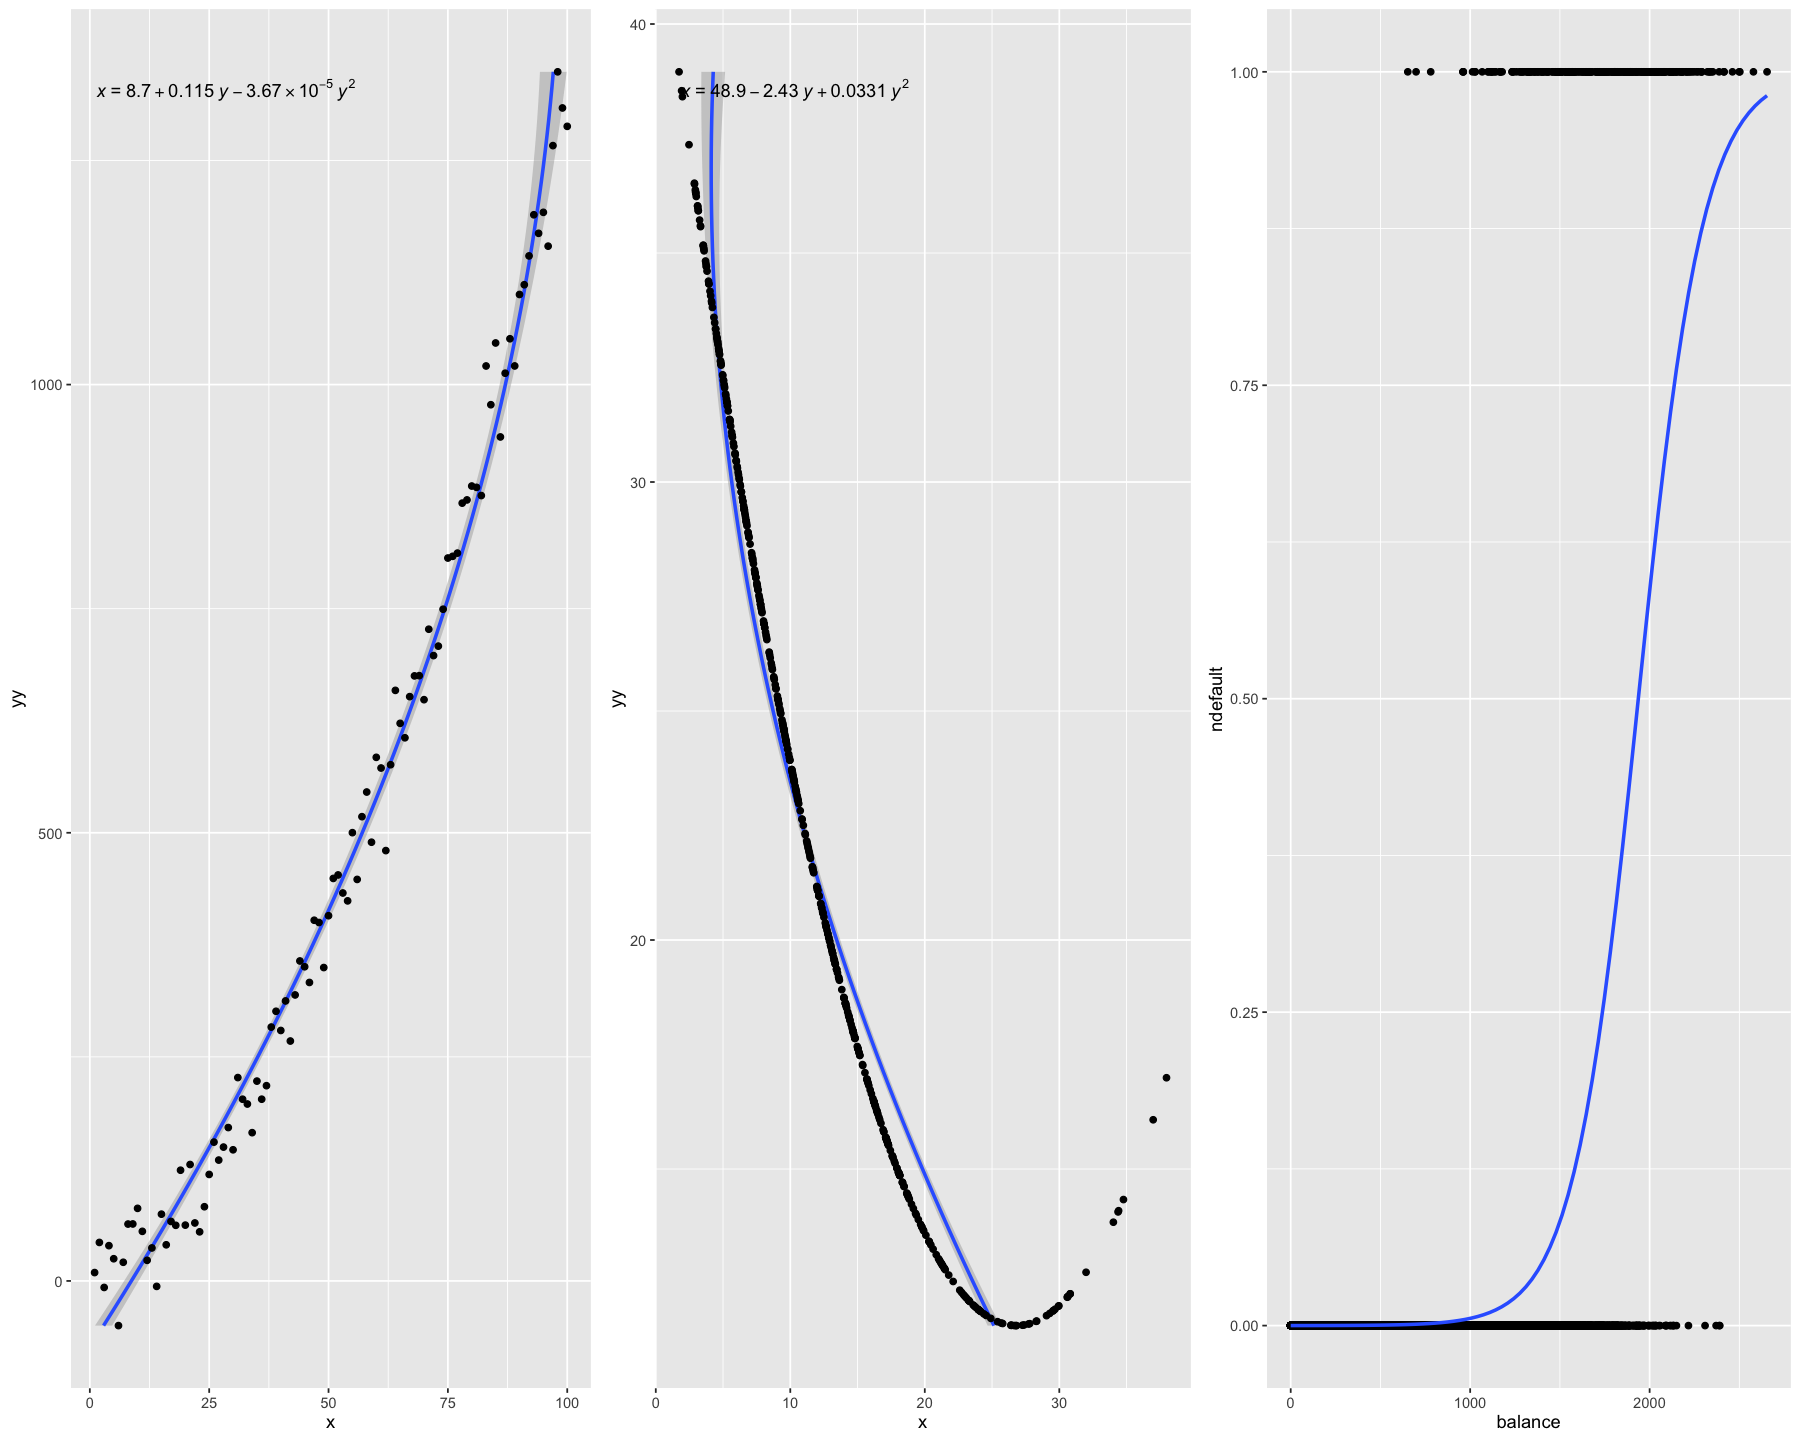

In [42]:
options(repr.plot.width = 15, repr.plot.height = 12)
grid.arrange(f1, f2, f3, ncol = 3)